<a href="https://colab.research.google.com/github/Lio72rga/Mineria-de-Datos-2026/blob/main/AO4_Clase5_Lionel_Martinez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clase 5 - Limpieza y Transformación de Datos
Notebook Actividad Integradora Minería de Datos

En esta actividad trabajé el proceso completo de preprocesamiento de datos, aplicando distintas técnicas de limpieza y transformación sobre datasets reales como Titanic y Diamantes.

## 1. Manejo de Datos Faltantes - Dataset Titanic

In [1]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")

# Ver valores nulos
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [2]:
# Eliminar filas con valores nulos en 'age'
df_cleaned = df.dropna(subset=["age"])

# Imputar con moda en 'embark_town'
df_cleaned["embark_town"].fillna(df_cleaned["embark_town"].mode()[0], inplace=True)

df_cleaned.isnull().sum()

/tmp/ipykernel_2598/1336963563.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned["embark_town"].fillna(df_cleaned["embark_town"].mode()[0], inplace=True)
/tmp/ipykernel_2598/1336963563.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["embark_town"].fillna(df_cleaned["embark_town"].mode()[0], inplace=True)


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


### Conclusión
Se eliminaron valores faltantes en edad y se imputaron en embark_town para mantener consistencia.

## 2. Outliers - Dataset Diamonds

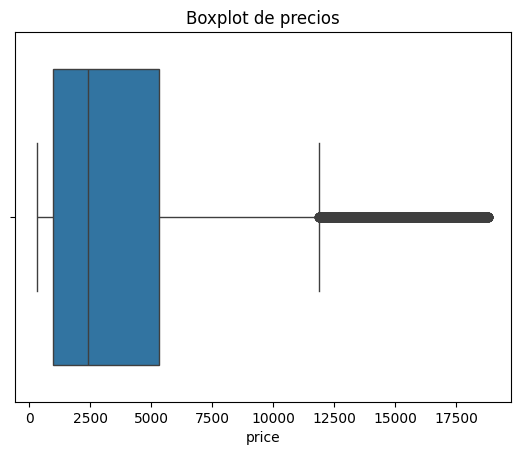

In [3]:
import matplotlib.pyplot as plt

df_diamonds = sns.load_dataset("diamonds")

sns.boxplot(x=df_diamonds["price"])
plt.title("Boxplot de precios")
plt.show()

In [4]:
# IQR
Q1 = df_diamonds["price"].quantile(0.25)
Q3 = df_diamonds["price"].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df_diamonds_clean = df_diamonds[(df_diamonds["price"] >= lim_inf) & (df_diamonds["price"] <= lim_sup)]

len(df_diamonds), len(df_diamonds_clean)

(53940, 50400)

### Conclusión
Se eliminaron outliers para mejorar la distribución de los datos.

## 3. Transformación de Datos

In [5]:
from sklearn.preprocessing import MinMaxScaler

df2 = sns.load_dataset("titanic")

# Normalización
scaler = MinMaxScaler()
df2["fare_norm"] = scaler.fit_transform(df2[["fare"]])

# One Hot Encoding
df2 = pd.get_dummies(df2, columns=["sex"], prefix="Sexo")

df2[["fare", "fare_norm", "Sexo_female", "Sexo_male"]].head()

,fare,fare_norm,Sexo_female,Sexo_male
0,7.2500,0.014151,False,True
1,71.2833,0.139136,True,False
2,7.9250,0.015469,True,False
3,53.1000,0.103644,True,False
4,8.0500,0.015713,False,True


### Conclusión
La normalización mejora la escala de los datos y One-Hot Encoding permite trabajar variables categóricas.

## 4. Ejercicio Integrador

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_final = pd.DataFrame({
    "Cliente":[1,2,3,4,5,6,7,8],
    "Edad":[25,40,35,50,30,45,38,29],
    "Ingresos":[50000,60000,70000,80000,45000,85000,72000,48000],
    "Historial_Pagos":["Bueno","Regular","Malo","Bueno","Regular","Malo","Bueno","Regular"],
    "Categoria":["A","B","C","A","B","C","A","B"]
})

# IQR
Q1 = df_final["Ingresos"].quantile(0.25)
Q3 = df_final["Ingresos"].quantile(0.75)
IQR = Q3 - Q1

df_final = df_final[(df_final["Ingresos"] >= Q1 - 1.5*IQR) & (df_final["Ingresos"] <= Q3 + 1.5*IQR)]

# Normalización
scaler = MinMaxScaler()
df_final["Ingresos_norm"] = scaler.fit_transform(df_final[["Ingresos"]])

# Estandarización
scaler2 = StandardScaler()
df_final["Edad_std"] = scaler2.fit_transform(df_final[["Edad"]])

# One-hot
df_final = pd.get_dummies(df_final, columns=["Historial_Pagos"])

# Label encoding
le = LabelEncoder()
df_final["Categoria_label"] = le.fit_transform(df_final["Categoria"])

df_final

,Cliente,Edad,Ingresos,Categoria,Ingresos_norm,Edad_std,Historial_Pagos_Bueno,Historial_Pagos_Malo,Historial_Pagos_Regular,Categoria_label
0,1,25,50000,A,0.125,-1.451747,True,False,False,0
1,2,40,60000,B,0.375,0.441836,False,False,True,1
2,3,35,70000,C,0.625,-0.189358,False,True,False,2
3,4,50,80000,A,0.875,1.704225,True,False,False,0
4,5,30,45000,B,0.000,-0.820553,False,False,True,1
5,6,45,85000,C,1.000,1.073030,False,True,False,2
6,7,38,72000,A,0.675,0.189358,True,False,False,0
7,8,29,48000,B,0.075,-0.946792,False,False,True,1


### Conclusión Final
Se aplicaron técnicas completas de limpieza y transformación, dejando los datos listos para modelado.

## Visualización adicional - Histogramas antes y después

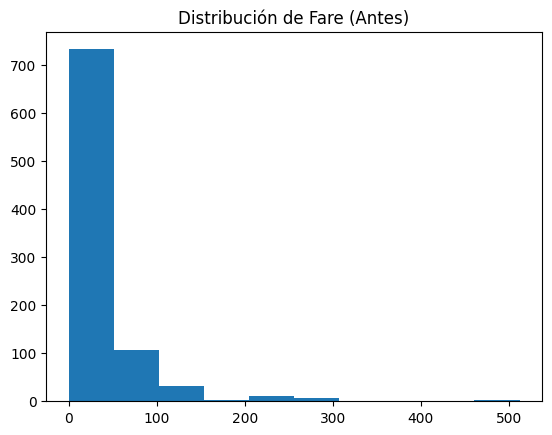

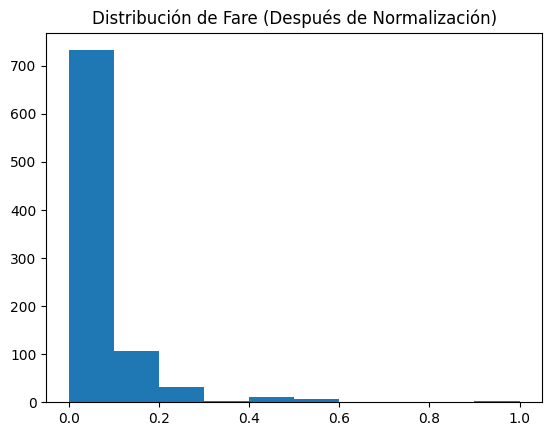

In [7]:
import matplotlib.pyplot as plt

# Titanic - Fare antes/después
df_titanic = sns.load_dataset("titanic")

plt.figure()
plt.hist(df_titanic["fare"].dropna())
plt.title("Distribución de Fare (Antes)")
plt.show()

# Después de normalización
scaler = MinMaxScaler()
fare_norm = scaler.fit_transform(df_titanic[["fare"]].dropna())

plt.figure()
plt.hist(fare_norm)
plt.title("Distribución de Fare (Después de Normalización)")
plt.show()

**Interpretación:**  
Antes de la normalización, la variable *fare* presenta una distribución sesgada con valores altos que generan una cola larga.  
Después de aplicar Min-Max Scaling, los valores se reescalan entre 0 y 1, manteniendo la forma de la distribución pero facilitando el trabajo de modelos sensibles a la escala.

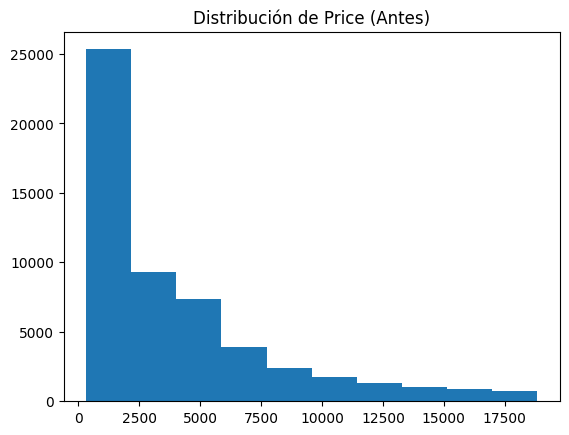

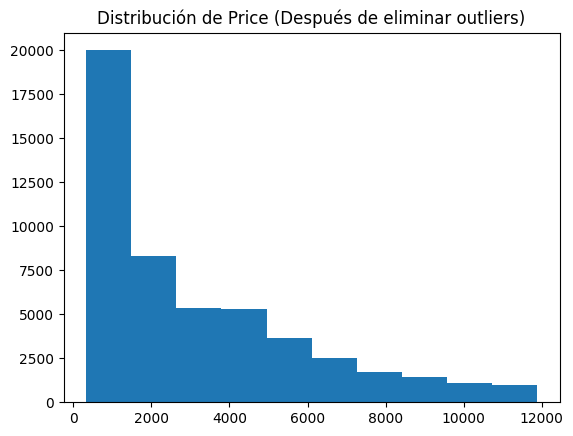

In [8]:
# Diamonds - Price antes/después

df_diamonds = sns.load_dataset("diamonds")

plt.figure()
plt.hist(df_diamonds["price"])
plt.title("Distribución de Price (Antes)")
plt.show()

# IQR limpieza
Q1 = df_diamonds["price"].quantile(0.25)
Q3 = df_diamonds["price"].quantile(0.75)
IQR = Q3 - Q1

df_clean = df_diamonds[(df_diamonds["price"] >= Q1 - 1.5*IQR) & (df_diamonds["price"] <= Q3 + 1.5*IQR)]

plt.figure()
plt.hist(df_clean["price"])
plt.title("Distribución de Price (Después de eliminar outliers)")
plt.show()

**Interpretación:**  
En la distribución original de *price* se observan valores extremos que afectan la forma general de los datos.  
Luego de eliminar outliers con el método IQR, la distribución se vuelve más concentrada y representativa del comportamiento general, lo que puede mejorar el rendimiento de modelos de Machine Learning.

# Conclusión General

Durante esta actividad se aplicaron distintas técnicas de limpieza y transformación de datos utilizando Python y bibliotecas como Pandas, Seaborn y Scikit-learn.

En la primera parte se trabajó el manejo de valores faltantes, aplicando estrategias de eliminación e imputación de datos. Estas técnicas permitieron mejorar la calidad y consistencia del dataset, evitando problemas en análisis posteriores.

Luego se realizó la detección y tratamiento de outliers mediante boxplots y el método IQR. La eliminación de valores extremos ayudó a obtener distribuciones más representativas y a reducir el impacto de datos atípicos sobre futuros modelos de Machine Learning.

También se aplicaron técnicas de transformación numérica, como normalización Min-Max y estandarización Z-score. Estas transformaciones resultan fundamentales para modelos sensibles a la escala de los datos, ya que mejoran la estabilidad y el rendimiento de los algoritmos.

En relación con las variables categóricas, se utilizaron técnicas de One-Hot Encoding y Label Encoding. One-Hot Encoding permitió representar categorías sin introducir relaciones ordinales inexistentes, mientras que Label Encoding facilitó la conversión compacta de variables categóricas.

Finalmente, esta actividad permitió comprender la importancia del preprocesamiento en minería de datos. Trabajar con datos limpios, consistentes y correctamente transformados mejora significativamente la calidad del análisis y aumenta la confiabilidad de los modelos predictivos.